# Session 4: Homework 2


In [2]:
# Import libraries

import pandas as pd
import pandas_datareader.data as web
import seaborn as sns
import numpy as np
from scipy import stats                # library for using advanced mathematical formulas & statistical techniques 
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from datetime import datetime, date
from skimpy import skim
import warnings
warnings.filterwarnings('ignore')


# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Climate change and temperature anomalies

If we wanted to study climate change, we can find data on the *Combined Land-Surface Air and Sea-Surface Water Temperature Anomalies* in the Northern Hemisphere at [NASA's Goddard Institute for Space Studies](https://data.giss.nasa.gov/gistemp). The [tabular data of temperature anomalies can be found here](https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.txt)

To define temperature anomalies you need to have a reference, or base, period which NASA clearly states that it is the period between 1951-1980.

In [2]:
# Load weather data
weather = pd.read_csv("https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.csv",
                      skiprows=1,
                      na_values="***")


# Data Inspection
print("Weather data info:")
print(weather.info()) # viewing different variables, their data types etc.
print("nFirst few rows:")
print(weather.head()) # Viewing the first 5 rows of the dataset

Weather data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    147 non-null    int64  
 1   Jan     147 non-null    float64
 2   Feb     147 non-null    float64
 3   Mar     147 non-null    float64
 4   Apr     147 non-null    float64
 5   May     147 non-null    float64
 6   Jun     147 non-null    float64
 7   Jul     147 non-null    float64
 8   Aug     146 non-null    float64
 9   Sep     146 non-null    float64
 10  Oct     146 non-null    float64
 11  Nov     146 non-null    float64
 12  Dec     146 non-null    float64
 13  J-D     146 non-null    float64
 14  D-N     145 non-null    float64
 15  DJF     146 non-null    float64
 16  MAM     147 non-null    float64
 17  JJA     146 non-null    float64
 18  SON     146 non-null    float64
dtypes: float64(18), int64(1)
memory usage: 21.9 KB
None
nFirst few rows:
   Year   Jan   Feb   Mar

You have two objectives in this section:

1. Select the year and the twelve month variables from the `weather` dataset. We do not need the others (J-D, D-N, DJF, etc.) for this assignment.
2. Convert the dataframe from wide to 'long' format. Name the new dataframe as `tidyweather`, name the variable containing the name of the month as `month`, and the temperature deviation values as `delta`.

In [3]:

# Select year and month columns
month_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# We create a subset of the dataframe containing the year & monthly data
weather_selected = weather[['Year'] + month_columns].copy() 

# Convert from wide to long format
tidyweather = weather_selected.melt(id_vars=['Year'],
                                    value_vars=month_columns, # we want the month variables to become elements within a single column
                                    var_name='month',         # the new column will be called 'month'
                                    value_name='delta')       # the values stored in the old monthly columns are now in a new column called delta

print("Tidy weather data:")
print(tidyweather.head())
print("nShape:", tidyweather.shape) # printing out the rows & columns of the new dataframe

Tidy weather data:
   Year month  delta
0  1880   Jan  -0.37
1  1881   Jan  -0.31
2  1882   Jan   0.25
3  1883   Jan  -0.58
4  1884   Jan  -0.16
nShape: (1764, 3)


## Plotting Information

Let us plot the data using a time-series scatter plot, and add a trendline. To do that, we first need to create a new variable called `date` in order to ensure that the `delta` values are plot chronologically.

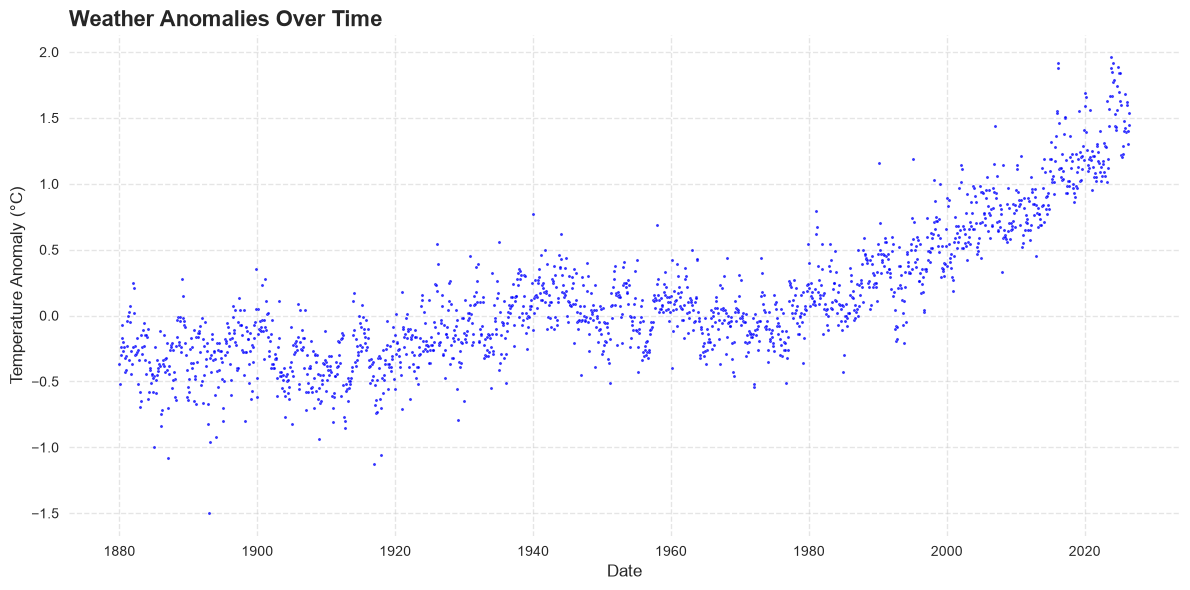

In [4]:

# Time series scatter-plot

# Data processing

# Convert year & month variables to datetime objects
tidyweather['date'] = pd.to_datetime(tidyweather['Year'].astype(str) + '-' + tidyweather['month'] + '-01',
                                    format='%Y-%b-%d', # format specifier
                                     errors='coerce')  # avoid crashes in case of invalid data

# retrieving cleaned date componenets
tidyweather['month_name'] = tidyweather['date'].dt.strftime('%b')
tidyweather['year'] = tidyweather['date'].dt.year

# 1. Set up the plotting window and style
# This creates the plotting window with a specific size (12 inches wide, 6 inches tall)
plt.figure(figsize=(12, 6))

# Sets the visual style of the plot (clean background with tick marks on axes)
sns.set_style("ticks")

# 2. Build the scatter plot   with Seaborn
ax = sns.scatterplot(
    data=tidyweather,   # The DataFrame containing our weather data
    x='date',           # Date column for x-axis (Seaborn handles dates automatically)
    y='delta',          # Temperature anomaly column for y-axis
    alpha=0.8,          # Make points 80% opaque (20% transparent)
    s=5,                # Set point size to 5 (small points for time series)
    color='blue'        # Set scatter point color to blue
)

# 3. Customize plot labels and appearance
# Add a clear, descriptive title
ax.set_title('Weather Anomalies Over Time', 
             fontsize=16, 
             fontweight='bold',
             loc='left')        # Left-align title for modern look

# Set axis labels with appropriate font sizes
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)

# Add a subtle grid to help read values
# 'both' adds grid for both major and minor ticks
# linestyle='--' makes dashed lines, alpha=0.5 makes them light
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Optional: Format date axis if needed (uncomment if dates look crowded)
# plt.xticks(rotation=45)  # Rotate date labels for better readability

# 4. Final plot adjustments and display
plt.tight_layout()  # Automatically adjusts spacing to prevent text cutoff
plt.show()         # Display the completed plot


Is the effect of increasing temperature more pronounced in some months? Use faceting to produce a separate scatter plot for each month, again with a smoothing line.

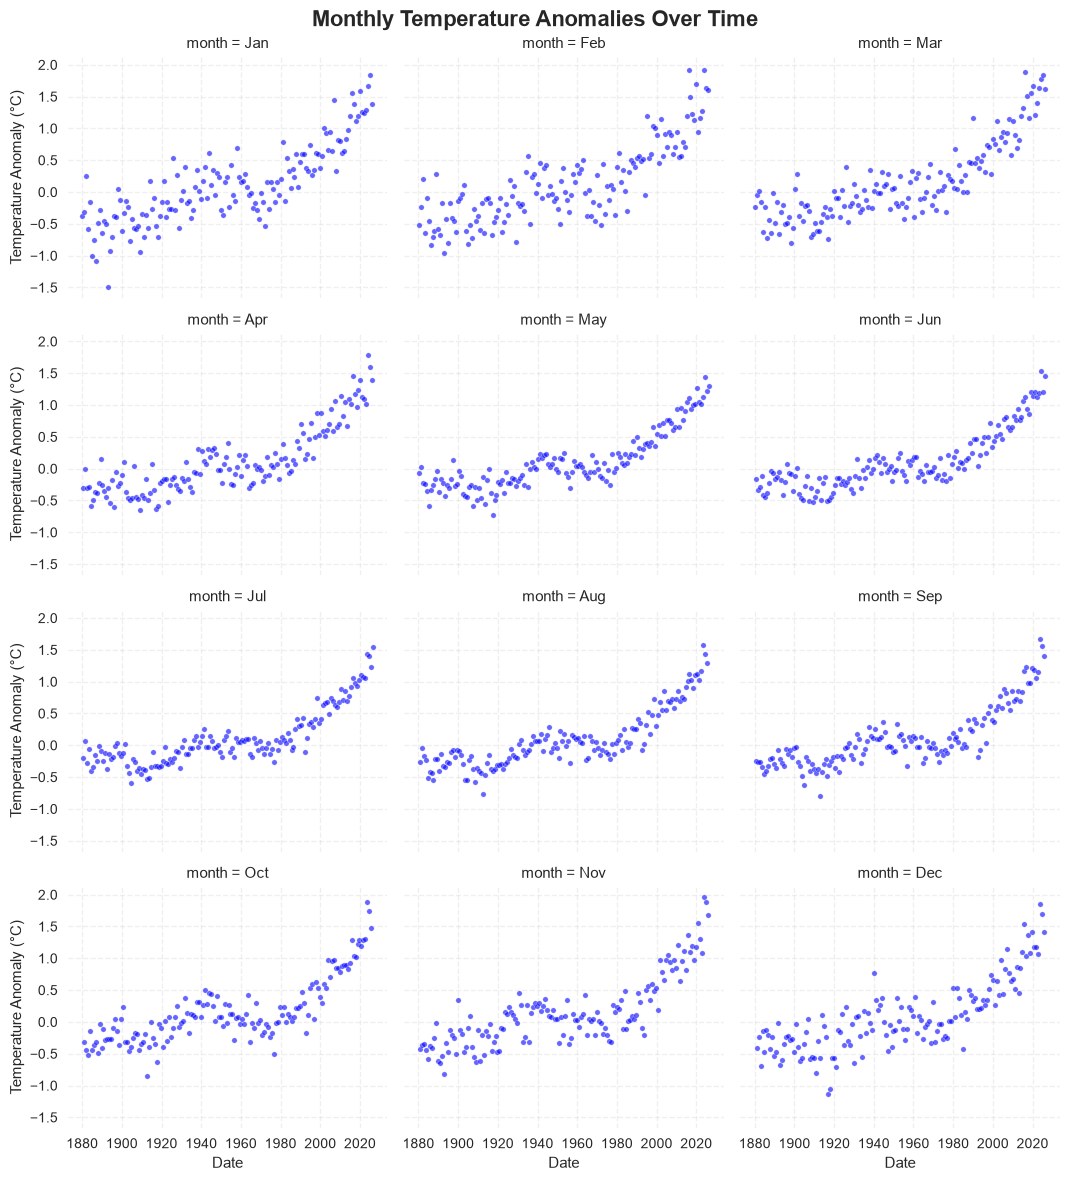

In [5]:
# Faceted plot by month using Seaborn's FacetGrid

# 1. Prepare the data - remove any rows with missing temperature or date data
# FacetGrid works best with clean data, so we remove NaN values upfront
clean_data = tidyweather.dropna(subset=['delta', 'date'])

# 2. Create the FacetGrid structure
# This automatically creates a 3x4 grid of subplots (one for each month)
g = sns.FacetGrid(
    clean_data,                    # The DataFrame containing our clean weather data
    col='month',                   # Create separate plots for each month
    col_wrap=3,                    # Wrap to new row after 3 columns 
    height=3,                      # Height of each individual subplot
    aspect=1.2,                    # Width/height ratio for each subplot (1.2 = slightly wider than tall)
    margin_titles=True             # Add month names as titles above each subplot
)

# 3. Add scatter plots to each facet
# The map() function applies sns.scatterplot to each subset of data
g.map(
    sns.scatterplot,               # Function to apply to each facet
    'date',                        # x-axis variable (date)
    'delta',                       # y-axis variable (temperature anomaly)
    alpha=0.6,                     # Make points 60% opaque for better visibility with many points
    s=15,                          # Point size (slightly larger than your original s=2 for visibility)
    color='blue'                   # All points will be blue
)

# 4. Customize the appearance of all subplots at once
# These settings apply to every facet in the grid

# Add axis labels to all subplots
g.set_axis_labels('Date',                           # x-axis label for all plots
                  'Temperature Anomaly (°C)')       # y-axis label for all plots

# Add a main title for the entire figure
g.fig.suptitle('Monthly Temperature Anomalies Over Time', 
               fontsize=16, 
               fontweight='bold',
               y=0.98)                              # Position title at top (y=0.98)

# Add subtle grid lines to all subplots
# We need to loop through each axis to add grids
for ax in g.axes.flat:
    ax.grid(True,                  # Enable grid
            alpha=0.3,             # Make grid lines light (30% opacity)
            linestyle='--')        # Use dashed lines for subtle appearance

# 5. Adjust layout and display
plt.tight_layout()                 # Automatically adjust spacing between subplots
plt.show()  

It is sometimes useful to group data into different time periods to study historical data. For example, we often refer to decades such as 1970s, 1980s, 1990s etc. to refer to a period of time. NASA calculates a temperature anomaly, as difference from the base period of 1951-1980.

In [6]:
# Create comparison dataframe with time intervals
comparison = tidyweather[tidyweather['Year'] >= 1881].copy()

# Here, we define a new function; this function will be used classifying our observations as belonging to specific interverals based on their year
def get_interval(year):
    if 1881 <= year <= 1920:
        return "1881-1920"
    elif 1921 <= year <= 1950:
        return "1921-1950"
    elif 1951 <= year <= 1980:
        return "1951-1980"
    elif 1981 <= year <= 2010:
        return "1981-2010"
    else:
        return "2011-present"

# Applying the get_interval function to create a new 'interval' variable

# We create e new column containing year intervals by applying our function on the Year column
comparison['interval'] = comparison['Year'].apply(get_interval) 

# The new column will have 5 categories in order from oldest to youngest interval (ordered categorical variable)
comparison['interval'] = pd.Categorical(comparison['interval'],
                                       categories=['1881-1920', '1921-1950', '1951-1980',
                                                   '1981-2010', '2011-present'],
                                       ordered=True)

print("Comparison data:")
print(comparison.head())

Comparison data:
   Year month  delta       date month_name  year   interval
1  1881   Jan  -0.31 1881-01-01        Jan  1881  1881-1920
2  1882   Jan   0.25 1882-01-01        Jan  1882  1881-1920
3  1883   Jan  -0.58 1883-01-01        Jan  1883  1881-1920
4  1884   Jan  -0.16 1884-01-01        Jan  1884  1881-1920
5  1885   Jan  -1.00 1885-01-01        Jan  1885  1881-1920


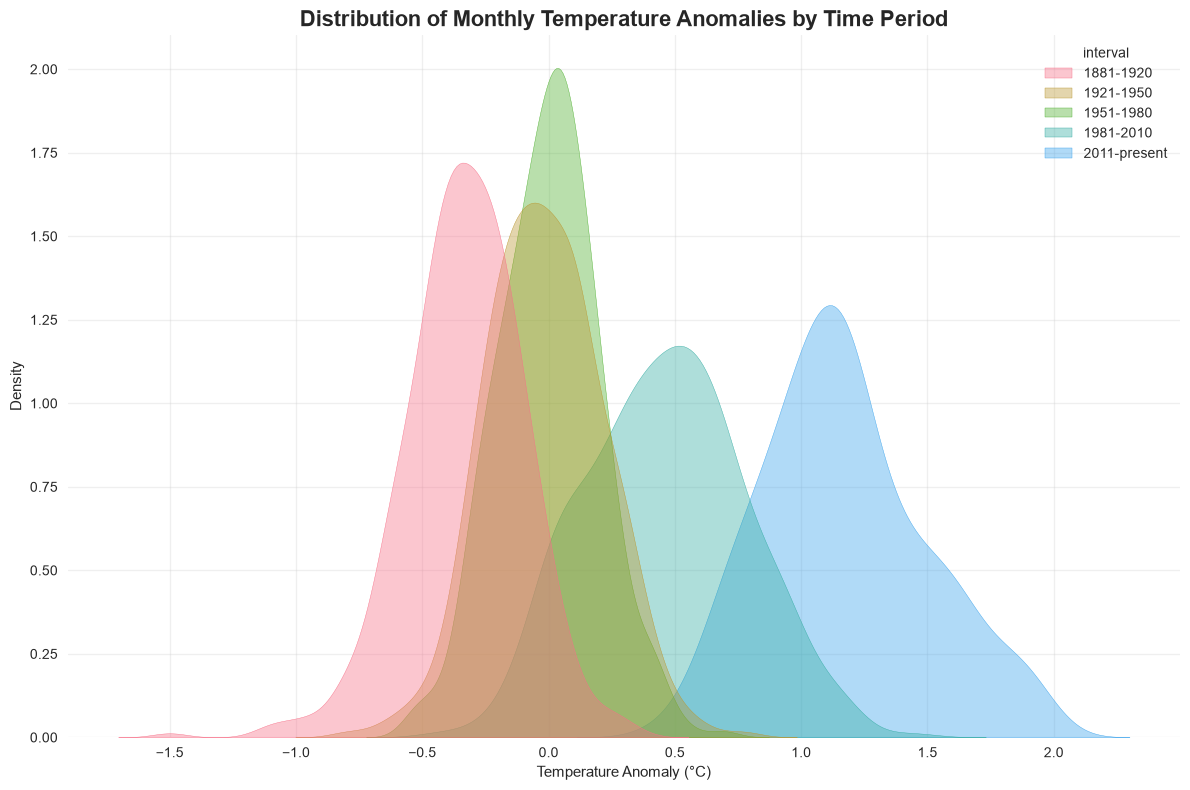

In [7]:
# Single plot with multiple density curves (one per interval)

# 1. Prepare the data - remove any rows with missing temperature data
# FacetGrid works best with clean data
clean_comparison = comparison.dropna(subset=['delta'])
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create density plot with different colors for each interval
ax = sns.kdeplot(data=clean_comparison, 
                 x='delta',              # Temperature anomaly on x-axis
                 hue='interval',         # Different colors for each interval
                 fill=True,              # Fill areas under curves
                 alpha=0.4,              # Semi-transparent fills
                 common_norm=False)      # Each curve shows its own distribution

# Customize the single plot
ax.set_title('Distribution of Monthly Temperature Anomalies by Time Period',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Temperature Anomaly (°C)')
ax.set_ylabel('Density')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

So far, we have been working with monthly anomalies. However, we might be interested in average annual anomalies. We can do this by using `group_by()` and `mean()`, followed by a scatter plot to display the result.

--- Annual Average Temperature Anomalies ---
   Year  avg_annual_anomaly
0  1880           -0.295000
1  1881           -0.182500
2  1882           -0.216667
3  1883           -0.282500
4  1884           -0.423333


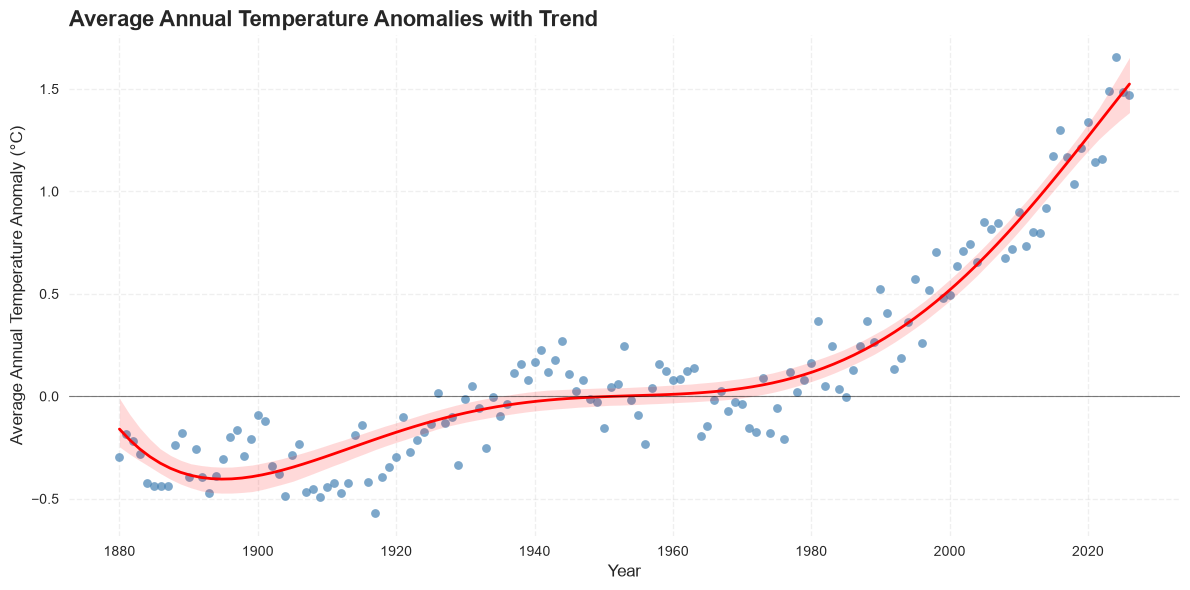

In [8]:
# Set up plot styling first
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create the plot using method chaining (pipe operations like dplyr in R)
# This approach chains multiple operations together for clean, readable code
plot_data = (tidyweather
             # Step 1: Remove any rows with missing temperature data
             # dropna() ensures we only work with complete records
             .dropna(subset=['delta'])
             
             # Step 2: Group data by year and calculate mean temperature anomaly
             # This collapses all monthly data within each year to a single average
             .groupby('Year')['delta']
             .mean()                                 # Calculate average anomaly for each year
             .reset_index()                          # Convert Series back to DataFrame
             
             # Step 3: Rename the column for clarity (optional but good practice)
             .rename(columns={'delta': 'avg_annual_anomaly'})
            )

# Display the processed data structure
print("--- Annual Average Temperature Anomalies ---")
print(plot_data.head())

# Create scatter plot with trend line using Seaborn
# sns.regplot automatically fits a regression line and creates scatter points
ax = sns.regplot(
    data=plot_data,                      # Use our chained/processed data
    x='Year',                            # Years on x-axis
    y='avg_annual_anomaly',              # Average annual anomalies on y-axis
    
    # Customize scatter points
    scatter_kws={
        'alpha': 0.7,                    # Make points 70% opaque for nice visibility
        'color': 'steelblue',            # Blue points for temperature data
        's': 40                          # Point size (larger than default for annual data)
    },
    
    # Customize the trend line
    line_kws={
        'color': 'red',                  # Red trend line for contrast
        'linewidth': 2                   # Thick line for visibility
    },
    
    # Use polynomial regression for curved trend line (like LOESS)
    order=5                              # 2nd degree polynomial (quadratic curve)
)

# Customize plot appearance using method chaining on the axes object
# This applies professional formatting to make the plot publication-ready
(ax.set_title('Average Annual Temperature Anomalies with Trend', 
              fontsize=16, 
              fontweight='bold',
              loc='left')                        # Left-align title for modern look
   .figure                                   # Access the figure object
)

# Set axis labels with descriptive text
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Annual Temperature Anomaly (°C)', fontsize=12)

# Add subtle grid for easier reading (seaborn style already includes basic grid)
ax.grid(True, alpha=0.3, linestyle='--')

# Add a horizontal reference line at zero
# This helps viewers quickly identify positive vs negative anomalies
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)

# Final layout adjustments and display
plt.tight_layout()                       # Prevent any text cutoff
plt.show()   

## Confidence Interval for `delta`

[NASA points out on their website](https://earthobservatory.nasa.gov/world-of-change/decadaltemp.php) that

> A one-degree global change is significant because it takes a vast amount of heat to warm all the oceans, atmosphere, and land by that much. In the past, a one- to two-degree drop was all it took to plunge the Earth into the Little Ice Age.

Your task is to construct a confidence interval for the average annual delta since 2011, both using a formula and using a bootstrap simulation.

In [9]:
# Calculate CI using formula for 2011-present

# First, we create a subset by filtering data for our chosen interval and dropping missing values
recent_data = comparison[comparison['interval'] == '2011-present']['delta'].dropna()

# Computing stats
mean_delta = recent_data.mean()              # calculating the mean
sd_delta = recent_data.std()                 # computing the standard deviation
count = len(recent_data)                     # getting a count of the total no. of observations in the subset
se_delta = sd_delta / np.sqrt(count)         # calculating the standard error using its formula
t_critical = stats.t.ppf(0.975, count - 1)   # computing the critical t-value for a 95% confidence interval
margin_of_error = t_critical * se_delta      # calculating the margin of error

# Building our confidence intervals
ci_lower = mean_delta - margin_of_error  # lower CI
ci_upper = mean_delta + margin_of_error  # upper CI

# Printing out the results
print(f"Formula-based Confidence Interval:")
print(f"Mean: {mean_delta:.4f}")
print(f"Standard Error: {se_delta:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

Formula-based Confidence Interval:
Mean: 1.1726
Standard Error: 0.0236
95% CI: [1.1261, 1.2191]


In [ ]:
# Bootstrap simulation

# We can also build the confidence interval using bootstrapping. Adjust the code from session3 to do this.

> What is the data showing us? Please type your answer after (and outside!) this blockquote. You have to explain what you have done, and the interpretation of the result. One paragraph max, please!

> TYPE YOUR ANSWER HERE

# Trump's Approval Margins

As we saw in class, we can get  detailed data on [all polls that track the president's approval](https://www.natesilver.net/p/trump-approval-ratings-nate-silver-bulletin)

In [ ]:
# Import approval polls data
approval_polllist = pd.read_csv(
    'https://static.dwcdn.net/data/kSCt4.csv?v=1787605980000',
    storage_options={'User-Agent': 'Mozilla/5.0'}
)
approval_polllist.head()


# Convert dates and create new columns
approval_polllist['modeldate'] = pd.to_datetime(approval_polllist['modeldate'])
approval_polllist['year'] = approval_polllist['modeldate'].dt.year
approval_polllist['week'] = approval_polllist['modeldate'].dt.isocalendar().week
approval_polllist['net_approval'] = approval_polllist['approve'] - approval_polllist['disapprove']

approval_polllist.tail()



,modeldate,approve,disapprove,approve_lo,approve_hi,disapprove_lo,disapprove_hi,year,week,net_approval
578,2026-08-22,38.08442,57.95539,32.97328,43.19556,52.93044,62.98035,2026,34,-19.87097
579,2026-08-23,38.08442,57.95539,32.97328,43.19556,52.93044,62.98035,2026,34,-19.87097
580,2026-08-24,38.35818,57.85210,33.26321,43.45315,52.94394,62.76026,2026,35,-19.49392
581,2026-08-25,38.19681,58.00367,32.95083,43.44279,52.85211,63.15524,2026,35,-19.80686
582,2026-08-26,38.23293,58.17485,33.22780,43.23806,53.19981,63.14989,2026,35,-19.94192


## Create a plot

What I would like you to do is to calculate the average net approval rate (approve- disapprove) for each week since he got into office. I want you plot the net approval for each week in 2026 along with its 95% confidence interval.

In [11]:
# Calculate weekly averages for 2026

# This approach flows from filtering → grouping → calculating → formatting in one readable sequence

# Display the processed data to verify our calculations
print("--- Weekly 2026 Approval Data with Confidence Intervals ---")
print(weekly_2026.head())

# Create the visualization using Seaborn's  plotting functions
# Set up the plotting style for professional appearance


--- Weekly 2026 Approval Data with Confidence Intervals ---


NameError: name 'weekly_2026' is not defined

# Avocados!

The data comes from the Hass Avocado Board and provides weekly sales (total volume in pounds (lbs) and average price in $/lb) in a number of regions around the US. You can find more about the data here https://www.kaggle.com/datasets/timmate/avocado-prices-2020




In [18]:
# ---------------------------------------------------------------------
# Global viz/theme settings (Seaborn-first)
# ---------------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="husl", context="talk")

# ---------------------------------------------------------------------
# Data: Hass avocado sales and prices (Kaggle)
# https://www.kaggle.com/datasets/timmate/avocado-prices-2020
# Notes:
# - 'units' = pounds in the HAB data
# - PLU codes:
#   4046: small/medium Hass (~3-5 oz)
#   4225: large Hass (~8-10 oz)
#   4770: extra large Hass (~10-15 oz)
# ---------------------------------------------------------------------
avocado = (
    pd.read_csv("../data/avocado.csv", parse_dates=["date"])
      .assign(
          # Make some columns categorical for efficiency and clearer semantics
          type=lambda d: d["type"].astype("category"),
          region=lambda d: d["region"].astype("category")
      )
)

avocado['date'] = pd.to_datetime(avocado['date'], dayfirst=True)

Please use your data manipulation and visualization skills to answer the following questions:

Task 1: Total volume by date (weekly sale


In [ ]:
# Task 1: Total volume by date (weekly sale


Task 2: Total volume by date and type (convetnional vs organic)


In [ ]:
# Task 2: Total volume by date and type (convetnional vs organic)


Task 3: For each date, % split conventional vs organic


In [ ]:
# Task 3: For each date, % split conventional vs organic


Task 4: Histogram of prices — conventional vs organic (Seaborn)
Two ways: overlaid (hue) and faceted


In [ ]:
# Task 4: Histogram of prices — conventional vs organic (Seaborn)


Task 5: Table — total volume and mean price by date


In [ ]:
# Task 5: Table — total volume and mean price by date


Task 6: Scatter (price vs volume) by type, with trend lines
Use seaborn lmplot (facetted) to show linear fit


In [ ]:
# Task 6: Scatter (price vs volume) by type, with trend lines


Task 7: Mean price by geography and type (table)


In [ ]:
# Task 7: Mean price by geography and type (table)


Task 8: Time series of mean prices by type (national mean across geographies)


In [ ]:
# Task 8: Time series of mean prices by type (national mean across geographies)


Task 9: Total volume by geography and type (table) + time series by type


In [ ]:
# Task 9: Total volume by geography and type (table) + time series by type


Task 10: Which geography generates most sales?
Exclude "Total U.S.", compute percent and cumulative percent; show top 10, table and barplot


In [ ]:
# Task 10: Which geography generates most sales?


Task 11: Price elasticity of demand (approx): Δvolume vs Δprice (ratios), calculation and scatterplot (sns.lmplot)


In [ ]:
# Task 11: Price elasticity of demand (approx): Δvolume vs Δprice (ratios), calculation and scatterplot (sns.lmplot)


Task 12: Cumulative change of price by type (normalize to first date = 1)


In [ ]:
# Task 12: Cumulative change of price by type (normalize to first date = 1)


Task 13: Prices in top 6 geographies (>4% of sales) over time
Facet by geography, hue by type


In [ ]:
# Task 13: Prices in top 6 geographies (>4% of sales) over time


# Challenge 1: Risk-Return Tradeoff Plot by year

Last week we downloaded prices of stocks from yahoo finance using `yfinance` and calcualted the risk-return tradeoff for each stock. However, that graph was for the toal time period. What if we wanted to produce a risk-return tradeoff for each of the past five years?

The code below will download the adjusted closing price for a few stocks from Yahoo finance. Your task is to manipulate the data and to produce a graph that look like the one below. There is no need to reproduce evry single aesthetic detail of the plot-- the key is to get your data manipulation right!

The final graph should look like this:

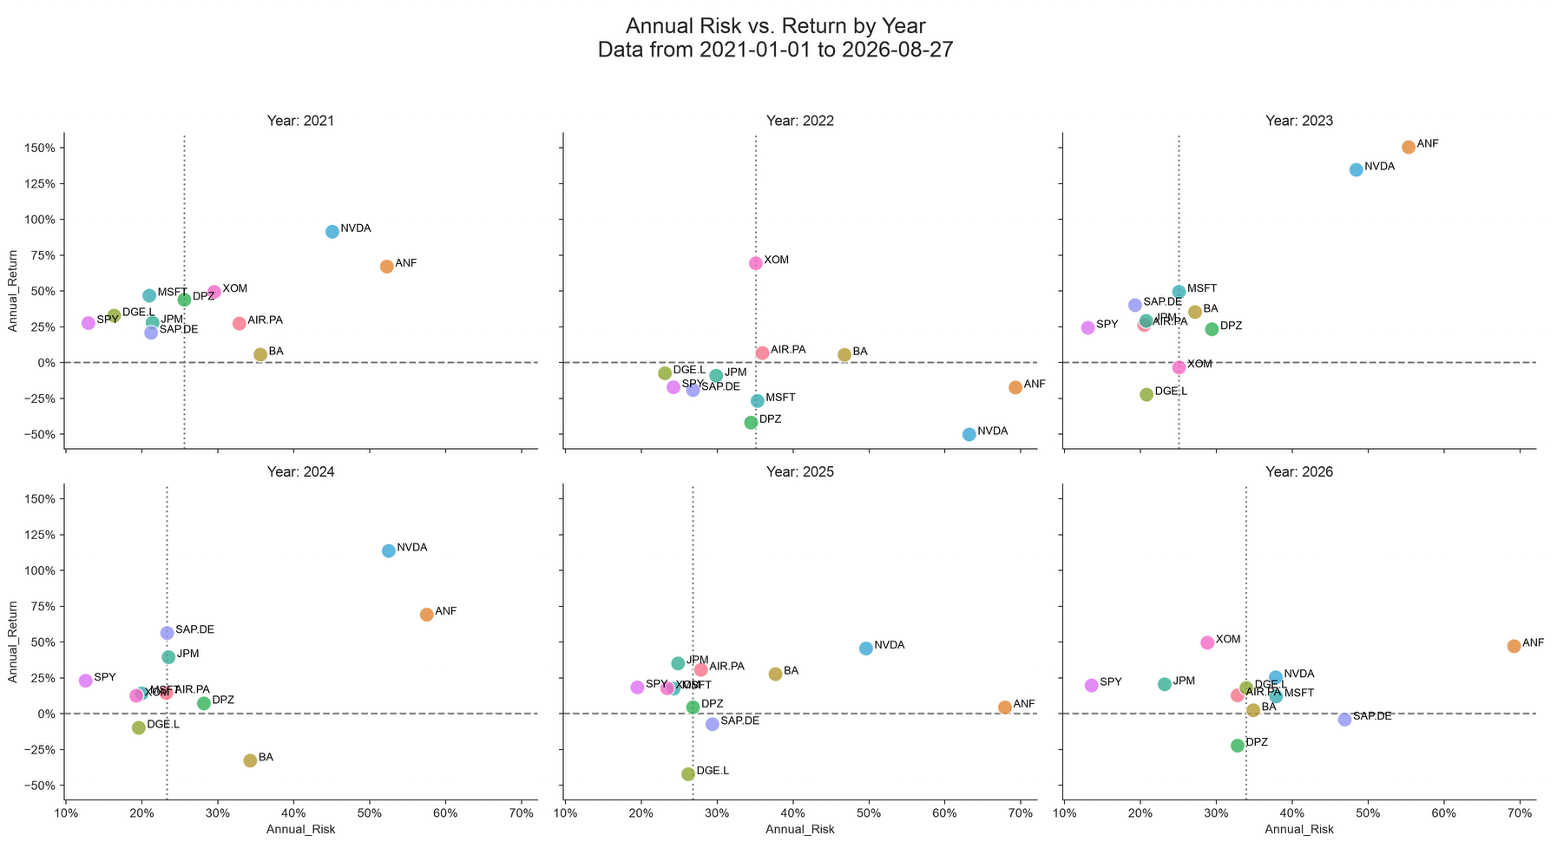

In [3]:
# =============================================================================
# 1. SETUP AND DATA DOWNLOAD
# =============================================================================
tickers = ['SPY', 'NVDA', 'AIR.PA', 'MSFT', 'BA', 'JPM', 'XOM','DGE.L','ANF','DPZ', 'SAP.DE']

# Dynamically set the date range for the last 5 full years
end_date = date.today()
start_date = date(end_date.year - 5, 1, 1)
sns.set_style("ticks")

print(f"Downloading historical stock data from {start_date} to {end_date}...")
adj_close_df = yf.download(tickers,
                           start=start_date,
                           end=end_date,
                           auto_adjust=False)['Adj Close']

print("\n--- Downloaded Data (First 5 Rows) ---")
print(adj_close_df.head(5))

[*********************100%***********************]  11 of 11 completed


--- Downloaded Data (First 5 Rows) ---
Ticker         AIR.PA        ANF          BA        DGE.L         DPZ  \
Date                                                                    
2021-01-04  82.468246  20.490000  202.720001  2943.570068  352.243988   
2021-01-05  82.413193  21.370001  211.630005  2941.073975  353.951843   
2021-01-06  82.725113  22.240000  211.029999  2942.072021  357.228333   
2021-01-07  82.220543  21.209999  212.710007  2984.508301  355.668976   
2021-01-08  82.660904  21.530001  209.899994  3033.435059  360.903992   

Ticker             JPM        MSFT       NVDA     SAP.DE         SPY  \
Date                                                                   
2021-01-04  109.000519  207.565353  13.060796  95.391243  342.436890   
2021-01-05  109.593636  207.765610  13.350873  95.137634  344.795441   
2021-01-06  114.739700  202.378387  12.563803  95.536148  346.856720   
2021-01-07  118.507645  208.137451  13.290369  94.666656  352.010223   
2021-01-08  118.

# Challenge 2: Yield Curve Challenge

We have downloaded data on the US yield curve from 1960 to last month

Yield curve inversion occurs when short-term interest rates (3 months) exceed long-term rates (10 years), creating a downward-sloping yield curve instead of the normal upward slope. 

This unusual pattern has historically preceded most U.S. recessions, making it a closely watched economic indicator.

The code below will download the data on the yield curve from FRED-- eg, the 10 year bond is at https://fred.stlouisfed.org/series/DGS10. I got dates for US recessions from https://en.wikipedia.org/wiki/List_of_recessions_in_the_United_States and have added them in a `recessions` dataframe for you.

Your task is to manipulate the data and to produce a graph that look like the one below. There is no need to reproduce every single aesthetic detail of the plot-- the key is to get your data manipulation right. Besides your code, please explain how you approached this issue

The final graph should look like this:
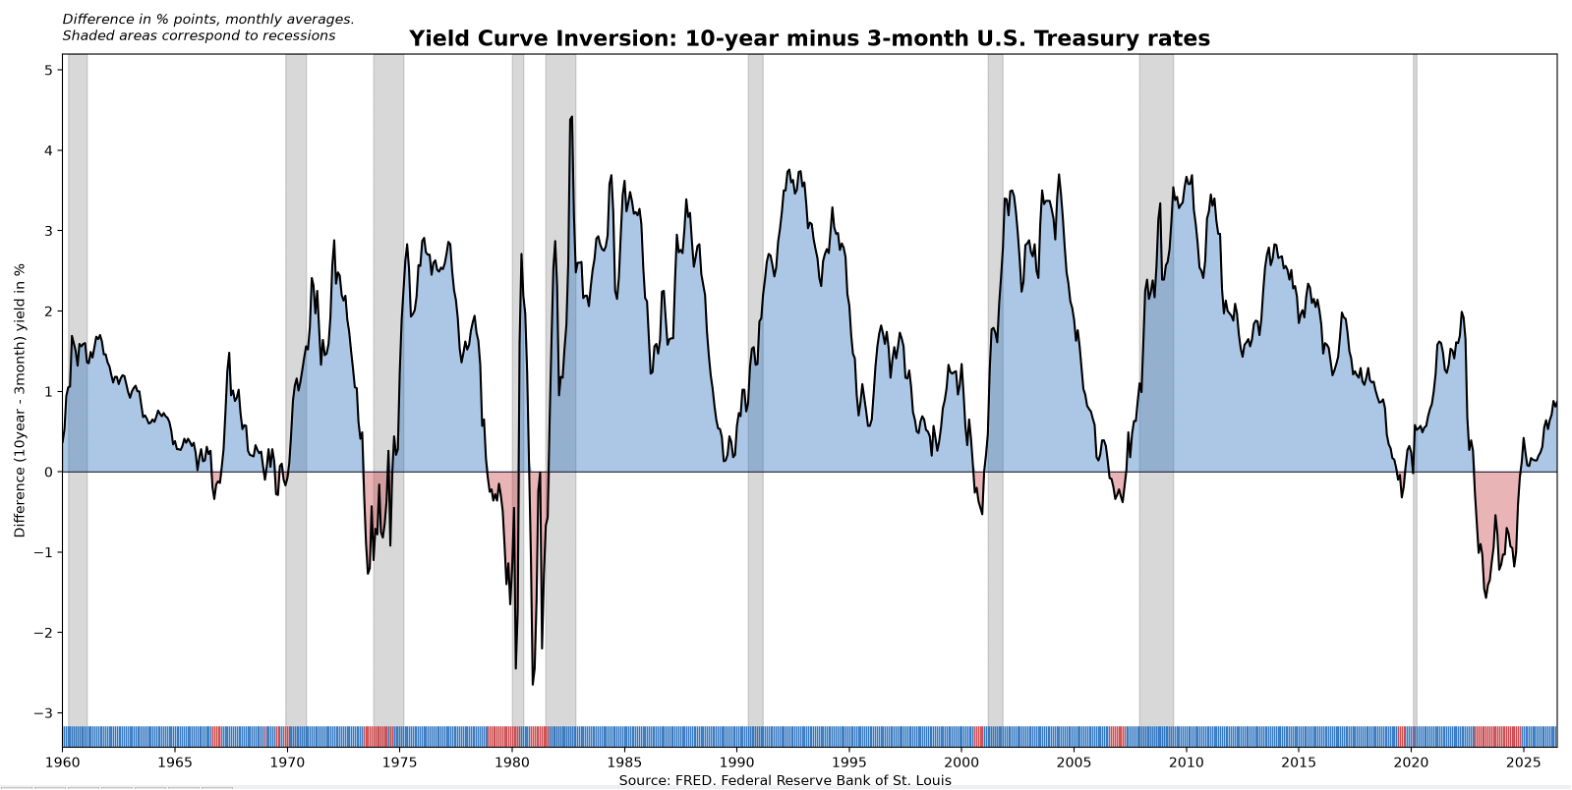




In [5]:
# --- Data Preparation ---

# Get a list of FRED codes for US rates and US yield curve; choose monthly frequency
tickers = [
    'TB3MS',  # 3-month Treasury bill (or T-bill)
    'TB6MS',  # 6-month
    'GS1',    # 1-year
    'GS2',    # 2-year, etc....
    'GS3',
    'GS5',
    'GS7',
    'GS10',
    'GS20',
    'GS30'    #.... all the way to the 30-year rate
]

# Turn FRED codes to human readable variables
myvars = [
    '3-Month Treasury Bill',
    '6-Month Treasury Bill',
    '1-Year Treasury Rate',
    '2-Year Treasury Rate',
    '3-Year Treasury Rate',
    '5-Year Treasury Rate',
    '7-Year Treasury Rate',
    '10-Year Treasury Rate',
    '20-Year Treasury Rate',
    '30-Year Treasury Rate'
]

maturity = ['3m', '6m', '1y', '2y', '3y', '5y', '7y', '10y', '20y', '30y']

# Create a lookup dataframe
mylookup = pd.DataFrame({
    'symbol': tickers,
    'var': myvars,
    'maturity': maturity
})

# Display the lookup table
print("--- Lookup Table ---")
print(mylookup)
print("\n")

# Use a function for a cleaner pipe
def prepare_yield_curve_data(df, lookup):
    """
    This function takes the raw data from FRED and the lookup table,
    and returns a clean, long-format DataFrame.
    """
    return (
        df
        .reset_index() # Turn the 'DATE' index into a column
        .rename(columns={'DATE': 'date'})
        # Melt the dataframe from wide to long format
        .melt(id_vars='date', var_name='symbol', value_name='value')
        # Merge with the lookup table to get human-readable names
        .merge(lookup, on='symbol')
        # Convert 'maturity' and 'var' to ordered categorical types
        # This is similar to R's factor() with specified levels
        .assign(
            maturity=lambda x: pd.Categorical(x['maturity'], categories=maturity, ordered=True),
            duration=lambda x: pd.Categorical(x['var'], categories=myvars, ordered=True)
        )
    )

# Fetch the data from FRED and process it using a chain of commands
yield_curve = (
    web.DataReader(tickers, 'fred', start='1960-01-01')
    .pipe(prepare_yield_curve_data, mylookup)
)

print("--- Yield Curve Data (First 5 Rows) ---")
print(yield_curve.head())
print("\n")


# Set up recession indicators
recessions = pd.DataFrame({
    'from': ["1948-11-01", "1953-07-01", "1957-08-01", "1960-04-01", "1969-12-01",
             "1973-11-01", "1980-01-01", "1981-07-01", "1990-07-01", "2001-03-01",
             "2007-12-01", "2020-02-01"],
    'to': ["1949-10-01", "1954-05-01", "1958-04-01", "1961-02-01", "1970-11-01",
           "1975-03-01", "1980-07-01", "1982-11-01", "1991-03-01", "2001-11-01",
           "2009-06-01", "2020-04-01"]
}).pipe(lambda df: df.assign(
    From=pd.to_datetime(df['from']),
    To=pd.to_datetime(df['to'])
))

--- Lookup Table ---
  symbol                    var maturity
0  TB3MS  3-Month Treasury Bill       3m
1  TB6MS  6-Month Treasury Bill       6m
2    GS1   1-Year Treasury Rate       1y
3    GS2   2-Year Treasury Rate       2y
4    GS3   3-Year Treasury Rate       3y
5    GS5   5-Year Treasury Rate       5y
6    GS7   7-Year Treasury Rate       7y
7   GS10  10-Year Treasury Rate      10y
8   GS20  20-Year Treasury Rate      20y
9   GS30  30-Year Treasury Rate      30y


--- Yield Curve Data (First 5 Rows) ---
        date symbol  value                    var maturity  \
0 1960-01-01  TB3MS   4.35  3-Month Treasury Bill       3m   
1 1960-02-01  TB3MS   3.96  3-Month Treasury Bill       3m   
2 1960-03-01  TB3MS   3.31  3-Month Treasury Bill       3m   
3 1960-04-01  TB3MS   3.23  3-Month Treasury Bill       3m   
4 1960-05-01  TB3MS   3.29  3-Month Treasury Bill       3m   

                duration  
0  3-Month Treasury Bill  
1  3-Month Treasury Bill  
2  3-Month Treasury Bill  
3  3-

## Details
- Who did you collaborate with: TYPE NAMES HERE
- Approximately how much time did you spend on this problem set: ANSWER HERE
- What, if anything, gave you the most trouble: ANSWER HERE